In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("insurance_data.csv")
print(df.head())

   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


In [16]:
X = df[["age"]]
y = df["bought_insurance"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X)

In [19]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

logistic_output = logistic_model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, logistic_output)
print("\nAccuracy:")
print(round(accuracy * 100,2), "%")



Accuracy:
100.0 %


In [22]:
test_age = [[30]]

prediction = logistic_model.predict(test_age)

print("\nAge:", test_age[0][0])

if prediction[0] == 1:
    print("Bought Insurance")
else:
    print("Did Not Buy Insurance")


Age: 30
Did Not Buy Insurance


/home/intellect/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [23]:
print("\nComparison:\n")

for age, lin, log in zip(
        df.age,
        linear_pred,
        logistic_model.predict(X)):

    print("Age:", age,
          "| Linear:", round(lin,2),
          "| Logistic:", log)


Comparison:

Age: 22 | Linear: 0.18 | Logistic: 0
Age: 25 | Linear: 0.24 | Logistic: 0
Age: 47 | Linear: 0.72 | Logistic: 1
Age: 52 | Linear: 0.83 | Logistic: 1
Age: 46 | Linear: 0.7 | Logistic: 1
Age: 56 | Linear: 0.92 | Logistic: 1
Age: 55 | Linear: 0.9 | Logistic: 1
Age: 60 | Linear: 1.0 | Logistic: 1
Age: 62 | Linear: 1.05 | Logistic: 1
Age: 61 | Linear: 1.03 | Logistic: 1
Age: 18 | Linear: 0.09 | Logistic: 0
Age: 28 | Linear: 0.31 | Logistic: 0
Age: 27 | Linear: 0.28 | Logistic: 0
Age: 29 | Linear: 0.33 | Logistic: 0
Age: 49 | Linear: 0.76 | Logistic: 1
Age: 55 | Linear: 0.9 | Logistic: 1
Age: 25 | Linear: 0.24 | Logistic: 0
Age: 58 | Linear: 0.96 | Logistic: 1
Age: 19 | Linear: 0.11 | Logistic: 0
Age: 18 | Linear: 0.09 | Logistic: 0
Age: 21 | Linear: 0.15 | Logistic: 0
Age: 26 | Linear: 0.26 | Logistic: 0
Age: 40 | Linear: 0.57 | Logistic: 1
Age: 45 | Linear: 0.68 | Logistic: 1
Age: 50 | Linear: 0.79 | Logistic: 1
Age: 54 | Linear: 0.87 | Logistic: 1
Age: 23 | Linear: 0.2 | Logi

In [26]:
age_range = np.linspace(
    df.age.min(),
    df.age.max(),
    300
).reshape(-1,1)

logistic_curve = logistic_model.predict_proba(
    age_range
)[:,1]

/home/intellect/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


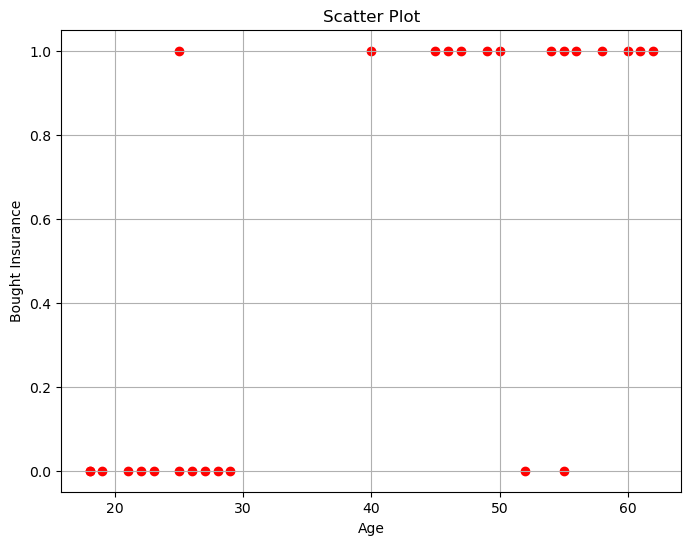

In [28]:
# ===================================
# GRAPH 1
# SCATTER PLOT
# ===================================

plt.figure(figsize=(8,6))

plt.scatter(
    df.age,
    df.bought_insurance,
    color='red'
)

plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Scatter Plot")

plt.grid(True)

plt.show()


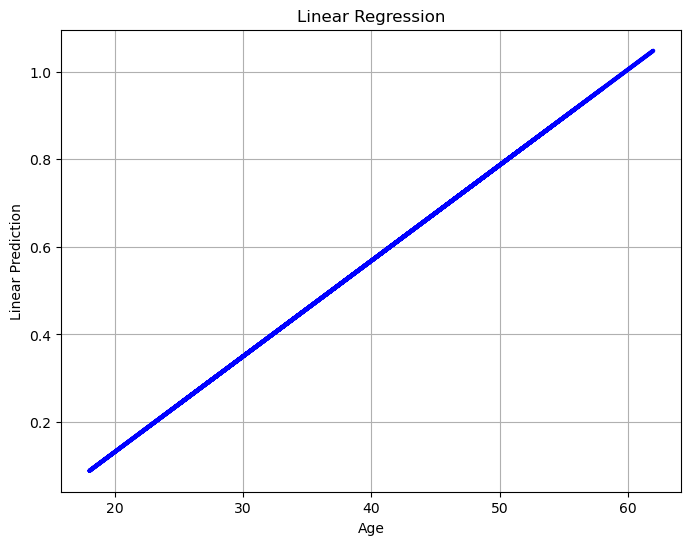

In [29]:
# ===================================
# GRAPH 2
# LINEAR REGRESSION
# ===================================

plt.figure(figsize=(8,6))

plt.plot(
    df.age,
    linear_pred,
    color='blue',
    linewidth=3
)

plt.xlabel("Age")
plt.ylabel("Linear Prediction")
plt.title("Linear Regression")

plt.grid(True)

plt.show()

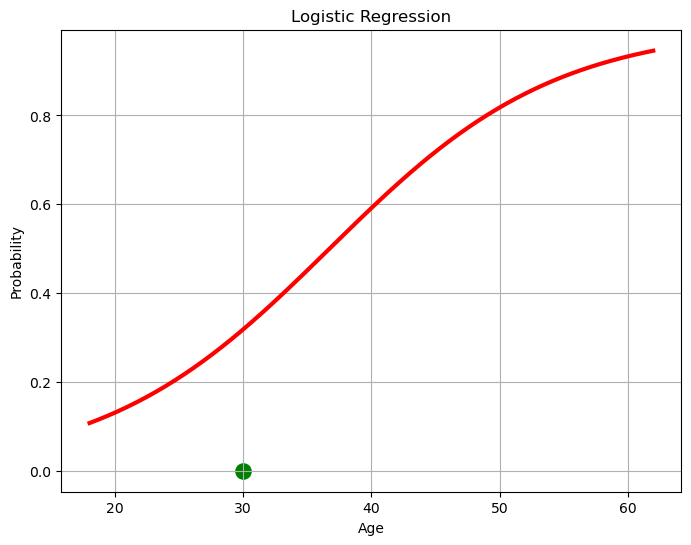

In [30]:
# ===================================
# GRAPH 3
# LOGISTIC REGRESSION
# ===================================

plt.figure(figsize=(8,6))

plt.plot(
    age_range,
    logistic_curve,
    color='red',
    linewidth=3
)

plt.scatter(
    test_age[0][0],
    prediction[0],
    color='green',
    s=120
)

plt.xlabel("Age")
plt.ylabel("Probability")
plt.title("Logistic Regression")

plt.grid(True)

plt.show()